# Week 6: Polynomial Regression, Overfitting & Regularization

## Student Practice Notebook

**Name:** PIYUSH RAJ  
**Roll Number:** AP24110010439  
**Date:** 11/09/2026

## Learning Objectives

After completing this lab, you will be able to:

- Engineer polynomial features and fit non-linear relationships with linear regression
- Recognize underfitting and overfitting from train vs. test performance
- Explain the bias-variance tradeoff in your own words
- Apply Ridge (L2), Lasso (L1), and ElasticNet regularization to fix an overfit model
- Explain why Lasso can zero out weights entirely while Ridge only shrinks them

### Why this week matters
Last week's linear model assumed a straight-line relationship. Real relationships often curve. This week you'll see what happens when a model gets too flexible — and how regularization reins it back in. This is the single most useful skill for making any model in your capstone project generalize, not just memorize.


## Part 0 — Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error

%matplotlib inline
np.random.seed(1)


## Part 1 — Polynomial Regression

### 1.1 Demo: a curved relationship


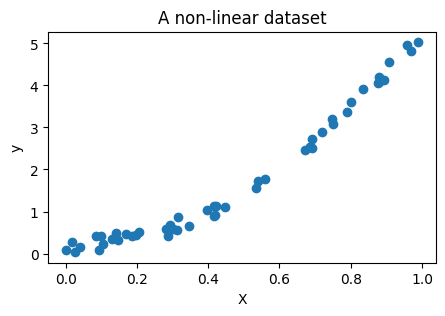

In [2]:
X_demo = np.random.rand(50, 1)
y_demo = (
    0.7 * X_demo ** 5 - 2.1 * X_demo ** 4 + 2.7 * X_demo ** 3
    + 3.5 * X_demo ** 2 + 0.3 * X_demo + 0.4 * np.random.rand(50, 1)
)

plt.figure(figsize=(5, 3))
plt.scatter(X_demo, y_demo)
plt.xlabel('X')
plt.ylabel('y')
plt.title('A non-linear dataset')
plt.show()


### 1.2 Fitting a plain (degree-1) line — does it work?

R2: 0.9345996128366808


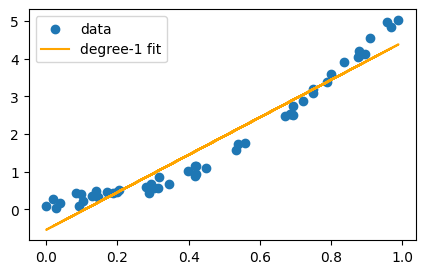

In [3]:
lin = LinearRegression()
lin.fit(X_demo, y_demo)
pred = lin.predict(X_demo)

print('R2:', lin.score(X_demo, y_demo))

plt.figure(figsize=(5, 3))
plt.scatter(X_demo, y_demo, label='data')
plt.plot(X_demo, pred, color='orange', label='degree-1 fit')
plt.legend()
plt.show()


**Your answer:** Yes. A degree-2 polynomial should fit noticeably better than a straight line because the dataset has a curved/non-linear relationship. The extra squared term lets the model bend instead of forcing the data into a straight line.


### Student Practice — fit a degree-3 polynomial

Use `PolynomialFeatures(degree=3, include_bias=False)` to transform `X_demo`, then fit a `LinearRegression` on the transformed features. Plot the result like the demo above (tip: sort `X_demo` before plotting the line, or the plot will look jagged).


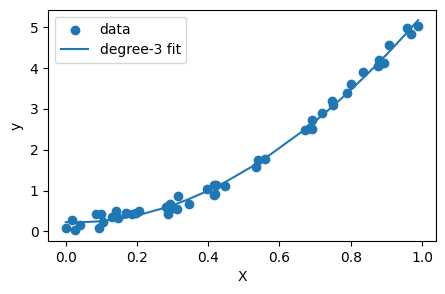

R2: 0.994924691754525


In [4]:
# Fit a degree-3 polynomial
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_demo_poly3 = poly3.fit_transform(X_demo)

poly3_model = LinearRegression()
poly3_model.fit(X_demo_poly3, y_demo)
pred3 = poly3_model.predict(X_demo_poly3)

# Sort X values so the fitted curve is plotted smoothly
order = np.argsort(X_demo[:, 0])
plt.figure(figsize=(5, 3))
plt.scatter(X_demo, y_demo, label='data')
plt.plot(X_demo[order], pred3[order], label='degree-3 fit')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

print('R2:', poly3_model.score(X_demo_poly3, y_demo))


## Part 2 — The Bias-Variance Tradeoff

We'll sweep polynomial degree from 1 to 25 on a train/test split, and watch what happens to train vs. test performance.


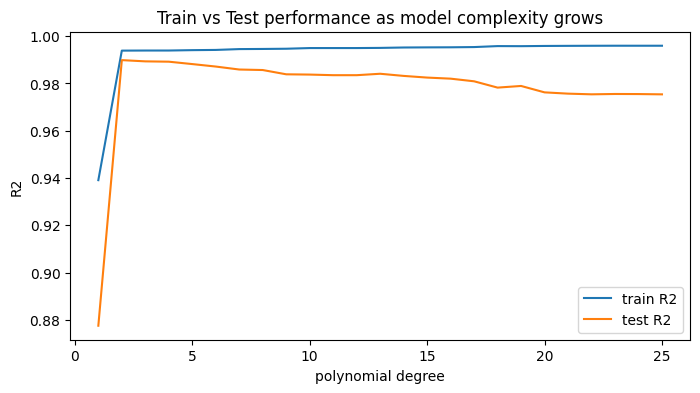

In [5]:
np.random.seed(1)
X_bv = np.random.rand(100, 1)
y_bv = (
    0.7 * X_bv ** 5 - 2.1 * X_bv ** 4 + 2.7 * X_bv ** 3
    + 3.5 * X_bv ** 2 + 0.3 * X_bv + 0.4 * np.random.rand(100, 1)
)

Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_bv, y_bv, test_size=0.3, random_state=1)

train_scores, test_scores = [], []
degrees = range(1, 26)

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    Xb_train_d = poly.fit_transform(Xb_train)
    Xb_test_d = poly.transform(Xb_test)

    m = LinearRegression()
    m.fit(Xb_train_d, yb_train)

    train_scores.append(m.score(Xb_train_d, yb_train))
    test_scores.append(m.score(Xb_test_d, yb_test))

plt.figure(figsize=(8, 4))
plt.plot(list(degrees), train_scores, label='train R2')
plt.plot(list(degrees), test_scores, label='test R2')
plt.xlabel('polynomial degree')
plt.ylabel('R2')
plt.legend()
plt.title('Train vs Test performance as model complexity grows')
plt.show()


### Student Practice — find the sweet spot

From the plot above (or by printing `test_scores`), find the degree with the **highest test R²**. Print that degree and its test score.


In [6]:
best_degree = list(degrees)[int(np.argmax(test_scores))]
best_test_r2 = max(test_scores)
print('Best degree:', best_degree)
print('Highest test R2:', best_test_r2)

# For this fixed random seed/split, degree 2 gives the highest test R2.


Best degree: 2
Highest test R2: 0.9898365606379398


**Your answer:**

- **Bias** is error caused by a model being too simple to capture the real pattern. A high-bias model tends to underfit.
- **Variance** is error caused by a model being too sensitive to the particular training data and its noise. A high-variance model tends to overfit.
- At **low polynomial degree**, bias is high and variance is low.
- At **high polynomial degree**, bias is low and variance is high.


## Part 3 — Regularization: Fixing an Overfit Model

We just saw high-degree polynomials overfit — they drive training error to near-zero by chasing noise. Regularization fights this by **penalizing large weights** directly in the loss function:

$$\text{Loss} = \text{MSE}(y, \hat{y}) + \lambda \times \text{penalty}(W)$$

- **Ridge (L2):** penalty = $\sum w_j^2$ — shrinks all weights smoothly toward zero, rarely exactly zero.
- **Lasso (L1):** penalty = $\sum |w_j|$ — can push weights **exactly to zero** (automatic feature selection). This happens because L1's penalty keeps pulling by the same fixed amount even as a weight nears zero, while L2's pull weakens the closer the weight already is to zero.
- **ElasticNet:** a blend of both, controlled by `l1_ratio`.

### 3.1 Demo: deliberately overfit, then rescue with Ridge/Lasso


In [7]:
overfit_degree = 25
poly_of = PolynomialFeatures(degree=overfit_degree, include_bias=False)
Xb_train_of = poly_of.fit_transform(Xb_train)
Xb_test_of = poly_of.transform(Xb_test)

# Regularization penalizes weight MAGNITUDE, so features must be on comparable scales first
poly_scaler = StandardScaler()
Xb_train_of_scaled = poly_scaler.fit_transform(Xb_train_of)
Xb_test_of_scaled = poly_scaler.transform(Xb_test_of)

plain_of = LinearRegression()
plain_of.fit(Xb_train_of_scaled, yb_train)

print('Plain Linear Regression, degree =', overfit_degree)
print('  Train MSE:', mean_squared_error(yb_train, plain_of.predict(Xb_train_of_scaled)))
print('  Test  MSE:', mean_squared_error(yb_test, plain_of.predict(Xb_test_of_scaled)))


Plain Linear Regression, degree = 25
  Train MSE: 0.010287929108736386
  Test  MSE: 0.04082622122487044


In [8]:
ridge_of = Ridge(alpha=1.0)
lasso_of = Lasso(alpha=0.01)
elastic_of = ElasticNet(alpha=0.01, l1_ratio=0.5)

for name, m in [('Ridge', ridge_of), ('Lasso', lasso_of), ('ElasticNet', elastic_of)]:
    m.fit(Xb_train_of_scaled, yb_train)
    train_mse = mean_squared_error(yb_train, m.predict(Xb_train_of_scaled))
    test_mse = mean_squared_error(yb_test, m.predict(Xb_test_of_scaled))
    print(f'{name:10s}  train MSE={train_mse:.5f}   test MSE={test_mse:.5f}')


Ridge       train MSE=0.01678   test MSE=0.02249
Lasso       train MSE=0.01552   test MSE=0.01754
ElasticNet  train MSE=0.01632   test MSE=0.02178


### Student Practice — tune the regularization strength

Try **three different values of `alpha`** for Ridge (e.g. 0.01, 1.0, 100.0). For each, fit, and print train/test MSE. Which `alpha` gives the best (lowest) test MSE? What happens at the extremes (too small or too large)?


In [9]:
# Try three Ridge regularization strengths
alphas = [0.01, 1.0, 100.0]
ridge_results = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(Xb_train_of_scaled, yb_train)
    train_mse = mean_squared_error(yb_train, model.predict(Xb_train_of_scaled))
    test_mse = mean_squared_error(yb_test, model.predict(Xb_test_of_scaled))
    ridge_results.append((alpha, train_mse, test_mse))
    print(f'alpha={alpha:<6} train MSE={train_mse:.5f}   test MSE={test_mse:.5f}')

best_alpha, _, best_test_mse = min(ridge_results, key=lambda x: x[2])
print('\nBest alpha:', best_alpha)
print('Lowest test MSE:', best_test_mse)
print('\nInterpretation: a very small alpha gives weak regularization and can leave overfitting; a very large alpha penalizes weights too strongly and can cause underfitting. The best value balances bias and variance.')


alpha=0.01   train MSE=0.01475   test MSE=0.01850
alpha=1.0    train MSE=0.01678   test MSE=0.02249
alpha=100.0  train MSE=0.19633   test MSE=0.20515

Best alpha: 0.01
Lowest test MSE: 0.01849963579495948

Interpretation: a very small alpha gives weak regularization and can leave overfitting; a very large alpha penalizes weights too strongly and can cause underfitting. The best value balances bias and variance.


### 3.2 L1 vs L2: sparsity in practice


In [10]:
n_zero_lasso = np.sum(np.isclose(lasso_of.coef_, 0))
n_zero_ridge = np.sum(np.isclose(ridge_of.coef_, 0))

print(f'Lasso: {n_zero_lasso} / {len(lasso_of.coef_)} weights driven to (near) zero')
print(f'Ridge: {n_zero_ridge} / {len(ridge_of.coef_)} weights driven to (near) zero')


Lasso: 22 / 25 weights driven to (near) zero
Ridge: 0 / 25 weights driven to (near) zero


**Your answer:** Too-small alpha means the regularization penalty is weak, so the high-degree model can still fit noise. This gives low bias but high variance (overfitting). Too-large alpha shrinks the weights too much, making the model overly simple. This gives higher bias and can cause underfitting. Therefore, we want an intermediate alpha that balances bias and variance and gives the lowest validation/test error.


## Summary

| What we did | Why it matters |
|---|---|
| Polynomial features | Fit curved relationships while still using linear regression under the hood. |
| Bias-variance sweep | Low degree = underfit (high bias); high degree = overfit (high variance). |
| Ridge / Lasso / ElasticNet | Penalize large weights to reduce overfitting; Lasso can also drive some weights to zero. |
| Tuned Ridge alpha | Shows that too little regularization can overfit, while too much can underfit. |

**Key takeaway:** Polynomial regression increases model flexibility, but high-degree models can overfit. Regularization controls this complexity by shrinking model coefficients and helps achieve a better bias-variance balance.
